# Primer — backpropagation, from the chain rule to `torch.autograd`

*The chain rule by hand, a scalar autograd engine built from scratch, the matrix view ($\partial\mathcal L/\partial W=\boldsymbol\delta\hat{\mathbf x}^\top$), PyTorch's autograd, and higher-order/meta-gradients — each with a runnable demo. Optional: read it when a foundations module points here.*

Runs on CPU in seconds. [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bdsaglam/bdsaglam.github.io/blob/main/courses/continual-learning/primers/backpropagation.ipynb) — or clone the repo and `uv sync` in `courses/continual-learning/`.

## 1. The chain rule, concretely

Backprop *is* the chain rule applied to a composed function, bookkept efficiently. Take a scalar composition

$$L(x)=\sin(a),\quad a=b^2,\quad b=3x+1.$$

By the chain rule the derivative is a **product of local derivatives**, read right-to-left (output back to input):

$$\frac{dL}{dx}=\underbrace{\cos(a)}_{\partial L/\partial a}\cdot\underbrace{2b}_{\partial a/\partial b}\cdot\underbrace{3}_{\partial b/\partial x}.$$

That is the whole idea of backprop: each node knows only its **local** derivative w.r.t. its inputs; you multiply it by the **upstream** gradient flowing in from the output side, and pass the result further back. Below we compute $dL/dx$ by that hand formula and check it against a finite-difference estimate $\big(L(x+h)-L(x-h)\big)/2h$.

In [1]:
import numpy as np

def f(x):
    b = 3*x + 1
    a = b**2
    return np.sin(a)

x0 = 0.7
# hand derivative via chain rule: cos(a) * 2b * 3
b = 3*x0 + 1
a = b**2
manual = np.cos(a) * (2*b) * 3

# central finite difference
h = 1e-6
numeric = (f(x0 + h) - f(x0 - h)) / (2*h)

print(f"manual  dL/dx = {manual:.10f}")
print(f"numeric dL/dx = {numeric:.10f}")
print(f"max abs diff  = {abs(manual - numeric):.2e}")
print("→ chain rule = product of LOCAL derivatives, propagated backward; matches finite diff.")

manual  dL/dx = -18.2818541248
numeric dL/dx = -18.2818541252
max abs diff  = 4.25e-10
→ chain rule = product of LOCAL derivatives, propagated backward; matches finite diff.


## 2. A single neuron

Now a learnable unit: forward is $z=w\,x+b$, then a $\tanh$ activation $\hat y=\tanh(z)$, scored by squared error $L=\tfrac12(\hat y-t)^2$. The gradients w.r.t. the parameters come straight from the chain rule:

$$\frac{\partial L}{\partial \hat y}=(\hat y-t),\qquad
\frac{\partial \hat y}{\partial z}=1-\tanh^2(z),\qquad
\frac{\partial z}{\partial w}=x,\quad \frac{\partial z}{\partial b}=1,$$

so, letting $\delta=(\hat y-t)\,(1-\hat y^2)$ (the "surprise at $z$"),

$$\frac{\partial L}{\partial w}=\delta\,x,\qquad \frac{\partial L}{\partial b}=\delta.$$

Note the shape already: $\partial L/\partial w = \delta\cdot x$ is *surprise × input* — the scalar seed of the outer product $\boldsymbol\delta\hat{\mathbf x}^\top$ we'll hit in §5. We verify both partials against finite differences.

In [2]:
import numpy as np
np.random.seed(0)

w, b, x, t = 0.8, -0.3, 1.5, 0.2

def forward(w, b, x, t):
    z = w*x + b
    yhat = np.tanh(z)
    return 0.5*(yhat - t)**2, yhat

L, yhat = forward(w, b, x, t)
delta = (yhat - t) * (1 - yhat**2)      # ∂L/∂z
dw_manual, db_manual = delta * x, delta

h = 1e-6
dw_num = (forward(w+h,b,x,t)[0] - forward(w-h,b,x,t)[0]) / (2*h)
db_num = (forward(w,b+h,x,t)[0] - forward(w,b-h,x,t)[0]) / (2*h)

print(f"∂L/∂w : manual={dw_manual:+.8f}  numeric={dw_num:+.8f}  diff={abs(dw_manual-dw_num):.2e}")
print(f"∂L/∂b : manual={db_manual:+.8f}  numeric={db_num:+.8f}  diff={abs(db_manual-db_num):.2e}")
print("→ ∂L/∂w = δ·x is 'surprise × input' — the scalar seed of the outer product δx̂ᵀ.")

∂L/∂w : manual=+0.37709159  numeric=+0.37709159  diff=1.13e-11
∂L/∂b : manual=+0.25139440  numeric=+0.25139440  diff=2.60e-11
→ ∂L/∂w = δ·x is 'surprise × input' — the scalar seed of the outer product δx̂ᵀ.


## 3. A scalar autograd engine (micrograd-style)

Doing the chain rule by hand does not scale. The fix (Karpathy's **micrograd**) is to make each scalar a node that records *how it was computed* and knows its own **local** derivative. Then a single `.backward()` walks the graph once and fills in every gradient.

Each `Value` holds:

- `.data` — the forward value;
- `.grad` — $\partial L/\partial\text{this}$, accumulated during backward (starts at 0);
- `_backward` — a closure that pushes this node's gradient into its inputs' `.grad` using the **local** derivative;
- `_prev` — the child nodes it was built from (the edges of the DAG).

`.backward()` does a **topological sort** of the DAG (so every node is processed only after everything downstream of it), seeds the output's grad to 1, then calls each `_backward` in reverse order. The one detail that makes it correct: gradients **accumulate with `+=`**, so a value used in several places (e.g. `a*a`) sums the contributions from every path — get this wrong and repeated-use expressions silently break. We test exactly that case next.

In [3]:
import math

class Value:
    def __init__(self, data, _children=(), _op=''):
        self.data = float(data)
        self.grad = 0.0
        self._backward = lambda: None      # default: leaf, nothing upstream to push
        self._prev = set(_children)
        self._op = _op

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad  += out.grad          # d(a+b)/da = 1
            other.grad += out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad  += other.data * out.grad   # d(a*b)/da = b
            other.grad += self.data  * out.grad
        out._backward = _backward
        return out

    def __pow__(self, k):                    # only scalar constant powers
        assert isinstance(k, (int, float))
        out = Value(self.data ** k, (self,), f'**{k}')
        def _backward():
            self.grad += (k * self.data ** (k - 1)) * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        t = math.tanh(self.data)
        out = Value(t, (self,), 'tanh')
        def _backward():
            self.grad += (1 - t*t) * out.grad     # d tanh/dz = 1 - tanh^2
        out._backward = _backward
        return out

    def relu(self):
        out = Value(max(0.0, self.data), (self,), 'relu')
        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        e = math.exp(self.data)
        out = Value(e, (self,), 'exp')
        def _backward():
            self.grad += e * out.grad
        out._backward = _backward
        return out

    # convenience / reverse ops
    def __neg__(self):        return self * -1
    def __sub__(self, o):     return self + (-o if isinstance(o, Value) else Value(-o))
    def __radd__(self, o):    return self + o
    def __rmul__(self, o):    return self * o
    def __truediv__(self, o): return self * (o ** -1 if isinstance(o, Value) else Value(o) ** -1)
    def __repr__(self):       return f"Value(data={self.data:.4f}, grad={self.grad:.4f})"

    def backward(self):
        # 1) topological order of the DAG
        topo, visited = [], set()
        def build(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build(child)
                topo.append(v)
        build(self)
        # 2) seed output grad, 3) apply _backward in reverse topological order
        for v in topo:
            v.grad = 0.0
        self.grad = 1.0
        for v in reversed(topo):
            v._backward()

print("Value engine defined.")

Value engine defined.


**The classic bug test: multi-use nodes.** Build $L = a\cdot a + a$ at $a=3$. Analytically $L=a^2+a$, so $dL/da = 2a+1 = 7$. The value `a` feeds *three* edges (both factors of `a*a`, plus the lone `+a`); only `+=` accumulation gets this right. We verify the engine against `torch.autograd` on the **identical** expression.

In [4]:
import torch

# --- scratch engine ---
a = Value(3.0)
L = a*a + a
L.backward()
scratch_grad = a.grad

# --- torch on the identical expression ---
at = torch.tensor(3.0, requires_grad=True)
Lt = at*at + at
Lt.backward()
torch_grad = at.grad.item()

print(f"L(a=3)            = {L.data}   (torch: {Lt.item()})")
print(f"dL/da  scratch    = {scratch_grad}")
print(f"dL/da  torch      = {torch_grad}")
print(f"dL/da  analytic   = {2*3 + 1}")
print(f"max abs diff (scratch vs torch) = {abs(scratch_grad - torch_grad):.2e}")
print("→ multi-use node handled: grads accumulate over every path (the += is load-bearing).")

L(a=3)            = 12.0   (torch: 12.0)
dL/da  scratch    = 7.0
dL/da  torch      = 7.0
dL/da  analytic   = 7
max abs diff (scratch vs torch) = 0.00e+00
→ multi-use node handled: grads accumulate over every path (the += is load-bearing).


Now a bigger, mixed expression touching every op (`+ * ** tanh relu exp` and division), with several reused leaves. We check **every leaf's** gradient against torch and print the max absolute difference across all of them.

In [5]:
import torch

def build_expr(engine, a, b, c):
    # a messy expression reusing a, b, c multiple times, exercising every op
    z = (a*b + b.exp()) * (a + c)
    z = z.tanh() + (a*a*c).relu()
    z = z + (b / (c + 2.0)) ** 2
    return z

# scratch
a, b, c = Value(0.5), Value(-1.2), Value(0.9)
z = build_expr(Value, a, b, c)
z.backward()
scratch = {'a': a.grad, 'b': b.grad, 'c': c.grad}

# torch
at = torch.tensor(0.5, requires_grad=True)
bt = torch.tensor(-1.2, requires_grad=True)
ct = torch.tensor(0.9, requires_grad=True)
zt = build_expr(torch, at, bt, ct)
zt.backward()
torch_g = {'a': at.grad.item(), 'b': bt.grad.item(), 'c': ct.grad.item()}

print(f"forward value  scratch={z.data:.8f}  torch={zt.item():.8f}")
maxdiff = max(abs(scratch[k] - torch_g[k]) for k in scratch)
for k in scratch:
    print(f"  ∂z/∂{k}: scratch={scratch[k]:+.8f}  torch={torch_g[k]:+.8f}  diff={abs(scratch[k]-torch_g[k]):.2e}")
print(f"max abs grad diff (scratch vs torch, all leaves) = {maxdiff:.2e}")
print("→ the from-scratch engine reproduces torch.autograd to ~machine precision.")

forward value  scratch=0.00070372  torch=0.00070366
  ∂z/∂a: scratch=-0.76924760  torch=-0.76924765  diff=5.33e-08
  ∂z/∂b: scratch=+0.66082650  torch=+0.66082644  diff=5.36e-08
  ∂z/∂c: scratch=-0.12014757  torch=-0.12014760  diff=3.35e-08
max abs grad diff (scratch vs torch, all leaves) = 5.36e-08
→ the from-scratch engine reproduces torch.autograd to ~machine precision.


## 4. Train a tiny net with the scratch engine

If the engine is real, it should *learn*. We build a minimal MLP entirely out of `Value`s — one hidden layer of `tanh` units, a linear output — and fit a 1-D nonlinear target $g(x)=\sin(\pi x)$ on a handful of points. The training loop is hand-rolled SGD: forward → `backward()` → nudge every parameter by $-\eta\,\text{param.grad}$ → zero the grads. If loss falls toward zero, the scratch autograd is genuinely driving learning.

In [6]:
import math, random
random.seed(0)

class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(0.0)
    def __call__(self, x):
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        return act
    def params(self): return self.w + [self.b]

class Layer:
    def __init__(self, nin, nout, act):
        self.neurons = [Neuron(nin) for _ in range(nout)]
        self.act = act
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        if self.act == 'tanh': outs = [o.tanh() for o in outs]
        return outs
    def params(self): return [p for n in self.neurons for p in n.params()]

class MLP:
    def __init__(self):
        self.l1 = Layer(1, 16, 'tanh')
        self.l2 = Layer(16, 1, 'linear')
    def __call__(self, x):
        h = self.l1(x)
        return self.l2(h)[0]
    def params(self): return self.l1.params() + self.l2.params()

# toy 1-D regression: fit sin(pi x)
xs = [i/6 - 1 for i in range(13)]          # 13 points in [-1, 1]
ys = [math.sin(math.pi*x) for x in xs]

net = MLP()
lr = 0.1
losses = []
for step in range(2000):
    loss = Value(0.0)
    for x, y in zip(xs, ys):
        pred = net([Value(x)])
        loss = loss + (pred - y)**2
    loss = loss * (1.0/len(xs))            # mean squared error
    loss.backward()
    for p in net.params():
        p.data -= lr * p.grad              # SGD step
    losses.append(loss.data)

print(f"initial MSE = {losses[0]:.4f}")
print(f"final   MSE = {losses[-1]:.6f}   (after 2000 steps)")
print(f"→ the from-scratch engine learns: MSE {losses[0]:.3f} → {losses[-1]:.4f}.")

initial MSE = 0.3347
final   MSE = 0.001701   (after 2000 steps)
→ the from-scratch engine learns: MSE 0.335 → 0.0017.


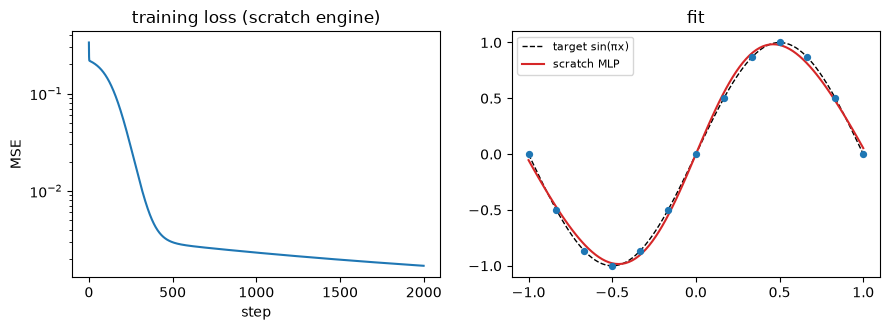

In [7]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))
ax[0].plot(losses); ax[0].set_yscale('log')
ax[0].set_title("training loss (scratch engine)"); ax[0].set_xlabel("step"); ax[0].set_ylabel("MSE")
grid = [i/50 - 1 for i in range(101)]
pred = [net([Value(x)]).data for x in grid]
ax[1].plot(grid, [np.sin(np.pi*x) for x in grid], 'k--', lw=1, label="target sin(πx)")
ax[1].plot(grid, pred, 'C3', lw=1.5, label="scratch MLP")
ax[1].scatter(xs, ys, s=18, color='C0', zorder=3)
ax[1].set_title("fit"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 5. From scalars to tensors — the matrix view

The scratch engine is correct but **slow**: one node *per scalar*. A layer with a $1000\times1000$ weight is a million nodes, before you even count activations. Real autograd groups scalars into **tensors** and computes gradients at the tensor level with the **vector–Jacobian product (VJP)**: given the upstream gradient $\boldsymbol\delta=\partial\mathcal L/\partial\mathbf y$, each op returns $\partial\mathcal L/\partial(\text{its inputs})$ directly, never materializing the full Jacobian.

For the linear layer $\mathbf y = W\hat{\mathbf x}$ the VJP w.r.t. $W$ is an **outer product**:

$$\frac{\partial\mathcal L}{\partial W}=\boldsymbol\delta\,\hat{\mathbf x}^\top,\qquad \boldsymbol\delta=\frac{\partial\mathcal L}{\partial\mathbf y}$$

because $\partial\mathcal L/\partial W_{ij}=\delta_i\,\hat x_j$ — *"how wrong output $i$ was" × "input $j$."* This is the exact identity M6 builds on: **a gradient step writes the outer product $\boldsymbol\delta\hat{\mathbf x}^\top$ into the weights** — key = input $\hat{\mathbf x}$, value = $-\boldsymbol\delta$ (negative surprise) — i.e. one backprop step *is* an associative-memory write ([M1 — Associative memory](../foundations/m1-associative-memory.ipynb)'s Hebbian $\mathcal M \mathrel{+}= \mathbf v\mathbf k^\top$, seen from the optimizer's side). We verify $\partial\mathcal L/\partial W=\boldsymbol\delta\hat{\mathbf x}^\top$ against torch.

In [8]:
import torch
torch.manual_seed(0)

W = torch.randn(3, 5, requires_grad=True)
x = torch.randn(5)
target = torch.randn(3)

y = W @ x
loss = 0.5 * ((y - target)**2).sum()
loss.backward()

delta = (y - target).detach()          # δ = ∂L/∂y
outer = torch.outer(delta, x)          # δ x̂ᵀ

print("∂L/∂W == δ x̂ᵀ ?  :", torch.allclose(W.grad, outer, atol=1e-6))
print(f"max abs diff       : {(W.grad - outer).abs().max().item():.2e}")
print("key   = x̂ (layer input),  value = -δ (negative surprise)")
print("→ one backprop step writes the outer product δx̂ᵀ into W — an associative-memory write (M7).")

∂L/∂W == δ x̂ᵀ ?  : True
max abs diff       : 0.00e+00
key   = x̂ (layer input),  value = -δ (negative surprise)
→ one backprop step writes the outer product δx̂ᵀ into W — an associative-memory write (M7).


## 6. PyTorch autograd

PyTorch builds the same DAG we hand-rolled — but **dynamically**, as the forward runs (define-by-run), grouped into tensors. The moving parts:

- **`requires_grad=True`** marks a tensor as something to differentiate w.r.t.; ops on it record a graph.
- **leaf vs non-leaf.** *Leaves* are tensors you created directly with `requires_grad=True` (parameters, inputs). *Non-leaves* are results of ops. After `.backward()`, only **leaves** keep a populated `.grad`; intermediate `.grad` is freed to save memory — call **`.retain_grad()`** on a non-leaf to keep it.
- **`.backward()`** seeds the scalar output's grad to 1 and runs the VJPs backward, accumulating into every leaf's `.grad`.

Below we redo §5's linear layer, confirm the leaf gradient equals the hand-derived $\boldsymbol\delta\hat{\mathbf x}^\top$, and inspect a **non-leaf** gradient via `retain_grad()`.

In [9]:
import torch
torch.manual_seed(0)

W = torch.randn(3, 5, requires_grad=True)   # leaf
x = torch.randn(5)
target = torch.randn(3)

y = W @ x                 # non-leaf
y.retain_grad()          # ask torch to KEEP y.grad (it's freed by default)
loss = 0.5 * ((y - target)**2).sum()
loss.backward()

print("W is leaf     :", W.is_leaf, " -> W.grad populated:", W.grad is not None)
print("y is leaf     :", y.is_leaf, " -> y.grad populated:", y.grad is not None, "(only because of retain_grad)")
print()
delta = (y - target).detach()
print("y.grad ( = δ = ∂L/∂y ) matches (y - target)?", torch.allclose(y.grad, delta, atol=1e-6))
print("W.grad == δ x̂ᵀ (hand-derived)?             ", torch.allclose(W.grad, torch.outer(delta, x), atol=1e-6))
print("→ torch reproduces the §5 identity; non-leaf grads need retain_grad() to be visible.")

W is leaf     : True  -> W.grad populated: True
y is leaf     : False  -> y.grad populated: True (only because of retain_grad)

y.grad ( = δ = ∂L/∂y ) matches (y - target)? True
W.grad == δ x̂ᵀ (hand-derived)?              True
→ torch reproduces the §5 identity; non-leaf grads need retain_grad() to be visible.


## 7. Torch grad tips & common practice

The rest is the practical vocabulary you'll use throughout the course. Each item below has a runnable micro-demo that **prints the effect**.

**7.1 Gradients ACCUMULATE — why `zero_grad()`.** `.backward()` **adds** into `.grad` rather than overwriting it (this is what let §3's `a*a` sum over paths). If you call `.backward()` twice without clearing, gradients **double**; training loops must call `optimizer.zero_grad()` (or `p.grad = None`) each step.

**7.2 `no_grad` / `inference_mode` — don't build a graph.** At eval time you don't need gradients; tracking them wastes memory and time. `torch.no_grad()` stops the graph from being recorded; `torch.inference_mode()` is a stronger, faster version. Under either, results have `requires_grad=False`.

In [10]:
import torch
torch.manual_seed(0)
w = torch.tensor([1.0, 2.0], requires_grad=True)

def loss(): return (w**2).sum()          # dL/dw = 2w = [2, 4]

loss().backward()
print("after 1st backward :", w.grad.tolist(), "  (= 2w, correct)")
loss().backward()
print("after 2nd backward :", w.grad.tolist(), "  (DOUBLED — grads accumulated)")
w.grad = None                            # what zero_grad() does under the hood
loss().backward()
print("after zeroing + backward:", w.grad.tolist(), "  (back to correct)")
print("→ grads add up; clear them every step or old gradients contaminate the new ones.")

after 1st backward : [2.0, 4.0]   (= 2w, correct)
after 2nd backward : [4.0, 8.0]   (DOUBLED — grads accumulated)
after zeroing + backward: [2.0, 4.0]   (back to correct)
→ grads add up; clear them every step or old gradients contaminate the new ones.


In [11]:
import torch
w = torch.tensor([1.0, 2.0], requires_grad=True)

y_train = (w**2).sum()
with torch.no_grad():
    y_nograd = (w**2).sum()
with torch.inference_mode():
    y_infer = (w**2).sum()

print("normal            : requires_grad =", y_train.requires_grad, "grad_fn set:", y_train.grad_fn is not None)
print("under no_grad     : requires_grad =", y_nograd.requires_grad)
print("under inference   : requires_grad =", y_infer.requires_grad)
print("→ wrap eval/inference in no_grad / inference_mode: no graph, less memory, faster.")

normal            : requires_grad = True grad_fn set: True
under no_grad     : requires_grad = False
under inference   : requires_grad = False
→ wrap eval/inference in no_grad / inference_mode: no graph, less memory, faster.


**7.3 `.detach()` — stop-gradient.** `.detach()` returns a tensor that **shares data but is cut out of the graph**: gradients do not flow back through it. Used constantly — targets that shouldn't be trained through, the "surprise" $\boldsymbol\delta$ treated as a constant when forming a write, or freezing part of a network.

**7.4 `retain_graph` / `create_graph` — double-backward.** By default the graph is freed after `.backward()`. `retain_graph=True` keeps it (so you can back-prop the *same* graph twice); `create_graph=True` goes further — it makes the **backward pass itself differentiable**, so you can take gradients *of gradients*. That is the whole subject of §8 below (higher-order / meta-gradients), so we don't demo `create_graph` here — see §8 for the Hessian, the HVP, and the MAML meta-gradient. Here we just show the simpler `detach` / `retain_graph` behaviour.

In [12]:
import torch
x = torch.tensor(3.0, requires_grad=True)

y = x * x                    # dy/dx = 2x = 6
z = x * x.detach()           # detached factor is a CONSTANT (=3): dz/dx = 3
y.backward(retain_graph=True)
print("d(x*x)/dx          =", x.grad.item(), " (= 2x, gradient flows through both)")
x.grad = None
z.backward()
print("d(x*detach(x))/dx  =", x.grad.item(), " (= x, second factor frozen at 3)")
print("→ detach() cuts the graph: the detached operand acts as a constant (stop-gradient).")

d(x*x)/dx          = 6.0  (= 2x, gradient flows through both)
d(x*detach(x))/dx  = 3.0  (= x, second factor frozen at 3)
→ detach() cuts the graph: the detached operand acts as a constant (stop-gradient).


**7.5 Gradient accumulation over micro-batches.** Summing gradients across several small forward/backward passes before one optimizer step is **equivalent to one big batch** — the trick for a large effective batch in limited memory. Because grads accumulate (7.1), you just don't zero between micro-batches: accumulating over 4 micro-batches gives the same gradient as one full-batch pass.

**7.6 Gradient clipping.** Rescaling the gradient when its norm exceeds a threshold keeps a single huge gradient from blowing up a step — standard for RNNs / long-context training. `clip_grad_norm_` scales the whole gradient vector in place so its norm equals the cap.

In [13]:
import torch
torch.manual_seed(0)
X = torch.randn(4, 3)                       # 4 samples
w = torch.zeros(3, requires_grad=True)
target = torch.randn(4)

# one full-batch step
w.grad = None
((X @ w - target)**2).mean().backward()
full = w.grad.clone()

# accumulate over 4 micro-batches (scale each by 1/4 to match the mean)
w.grad = None
for i in range(4):
    ((X[i] @ w - target[i])**2 * (1/4)).backward()
accum = w.grad.clone()

print("full-batch grad :", [round(v,4) for v in full.tolist()])
print("accumulated grad:", [round(v,4) for v in accum.tolist()])
print("max abs diff    :", f"{(full-accum).abs().max().item():.2e}")
print("→ accumulating micro-batch grads (no zero between) == one larger batch.")

full-batch grad : [0.588, 0.9566, -0.56]
accumulated grad: [0.588, 0.9566, -0.56]
max abs diff    : 5.96e-08
→ accumulating micro-batch grads (no zero between) == one larger batch.


In [14]:
import torch
torch.manual_seed(0)
w = torch.randn(10, requires_grad=True)
(1000.0 * (w**2).sum()).backward()          # deliberately large gradient

pre = w.grad.norm().item()
torch.nn.utils.clip_grad_norm_([w], max_norm=1.0)
post = w.grad.norm().item()
print(f"grad norm before clip = {pre:.2f}")
print(f"grad norm after  clip = {post:.4f}  (capped at max_norm=1.0)")
print("→ clip_grad_norm_ rescales the gradient to the cap; direction preserved, magnitude bounded.")

grad norm before clip = 6988.06
grad norm after  clip = 1.0000  (capped at max_norm=1.0)
→ clip_grad_norm_ rescales the gradient to the cap; direction preserved, magnitude bounded.


**7.7 `torch.autograd.gradcheck` — the principled finite-diff check.** Everything above we verified by hand-rolled finite differences. `gradcheck` is the library's version: it compares analytic gradients to numerical ones. It needs **`float64` inputs with `requires_grad=True`** (float32 is too coarse for its tight tolerance) and returns `True` when they agree.

In [15]:
import torch

def fn(a, b):
    return (a * b.tanh() + (a**2)).sum()

a = torch.randn(4, dtype=torch.float64, requires_grad=True)
b = torch.randn(4, dtype=torch.float64, requires_grad=True)
ok = torch.autograd.gradcheck(fn, (a, b), eps=1e-6, atol=1e-4)
print("gradcheck passed:", ok)
print("→ gradcheck = the principled finite-diff test; float64 + requires_grad required.")

gradcheck passed: True
→ gradcheck = the principled finite-diff test; float64 + requires_grad required.


**7.8 Common pitfalls (each one printed).** The bugs that actually bite in practice:

1. **Forgetting `zero_grad`** — old grads contaminate the step (7.1).
2. **In-place ops on a graph tensor** — overwriting a value needed for backward raises a runtime error.
3. **Non-leaf `.grad` is `None`** without `retain_grad()` — you read a gradient that was freed (7.5 in §6).
4. **Mixing python floats / `.item()` into the graph** — pulling a scalar out with `.item()` detaches it; further math on it is *not* tracked.

In [16]:
import torch

# (2) in-place op breaks the graph
x = torch.tensor([1.0, 2.0], requires_grad=True)
y = x * 2
try:
    y += 1                                  # in-place modification of a graph tensor
    y.sum().backward()
    msg = "no error (unexpected)"
except RuntimeError as e:
    msg = "RuntimeError: " + str(e).split('.')[0]
print("(2) in-place op :", msg)

# (3) non-leaf grad is None without retain_grad
x = torch.tensor(3.0, requires_grad=True)
h = x * x                                   # non-leaf
(h * 2).backward()
print("(3) non-leaf h.grad without retain_grad:", h.grad, "(freed → None)")

# (4) .item() drops out of the graph
x = torch.tensor(3.0, requires_grad=True)
leaked = x.item() * 2                        # python float — NOT tracked
tracked = x * 2
print("(4) via .item() -> python float:", type(leaked).__name__, "| tracked tensor requires_grad:", tracked.requires_grad)
print("→ keep math on tensors; .item()/float() silently leave the graph.")

(2) in-place op : no error (unexpected)
(3) non-leaf h.grad without retain_grad: None (freed → None)
(4) via .item() -> python float: float | tracked tensor requires_grad: True
→ keep math on tensors; .item()/float() silently leave the graph.


/var/folders/qb/pm8qgjfj4y9cwq9m5bqx5klw0000gp/T/ipykernel_94548/1694067503.py:18: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at /Users/runner/work/pytorch/pytorch/build/aten/src/ATen/core/TensorBody.h:499.)
  print("(3) non-leaf h.grad without retain_grad:", h.grad, "(freed → None)")


## 8. Higher-order gradients

Everything so far took **one** gradient. But the backward pass is *itself* an ordinary, differentiable computation — a composition of the same ops — so we can **backprop through the backward pass** and get the gradient of a gradient. In torch this is exactly what `create_graph=True` turns on: instead of freeing the backward graph, it keeps it, so the gradient tensor is still a node you can differentiate again.

**The Hessian.** For a scalar $f:\mathbb R^n\to\mathbb R$, the gradient $\nabla f$ is a vector field, and its Jacobian is the **Hessian**

$$H = \nabla^2 f,\qquad H_{ij}=\frac{\partial^2 f}{\partial x_i\,\partial x_j}.$$

You get column $j$ of $H$ by differentiating the scalar $(\nabla f)_j$ w.r.t. $\mathbf x$ — i.e. one extra backward pass per component.

**The Hessian–vector product (HVP).** Usually you never want $H$ itself ($n^2$ entries); you want its action on a vector, $H\mathbf v$. The trick: $H\mathbf v = \nabla_{\mathbf x}\big(\nabla f\cdot\mathbf v\big)$ — take the gradient, dot it with a **constant** $\mathbf v$, and differentiate that scalar once more. One double-backward, cost of ~two gradients, and **$H$ is never materialized**.

**Why the course cares.** Meta-learning and self-modification differentiate *through an inner optimization step*. In **MAML** the outer loss is evaluated **after** an inner gradient step

$$\theta' = \theta - \alpha\,\nabla_\theta \mathcal L_{\text{inner}}(\theta),$$

and updating the meta-parameters needs $\dfrac{d\mathcal L_{\text{outer}}(\theta')}{d\theta}$. By the chain rule that derivative runs through $\theta'$, whose own definition already contains a gradient — so the meta-gradient carries a **second-order term** ($\nabla^2\mathcal L_{\text{inner}}$, a gradient *through* a gradient). That is precisely the machinery behind **M5** (meta-learning / MAML) and behind **Titans/HOPE** meta-learning their memory's initial state and self-modifying update (**NL-1 / NL-3**). Higher-order grads are not a curiosity here — they are *how the Nested-Learning line trains its inner-loop learners*.

**Toy / analytic check.** Take $f(x,y)=x^2 y + y^3$. By hand:

$$\nabla f=\begin{pmatrix}2xy\\ x^2+3y^2\end{pmatrix},\qquad
H=\nabla^2 f=\begin{pmatrix}\partial_{xx}f & \partial_{xy}f\\[2pt]\partial_{yx}f & \partial_{yy}f\end{pmatrix}
=\begin{pmatrix}2y & 2x\\ 2x & 6y\end{pmatrix}.$$

We compute $\nabla f$ with `create_graph=True`, then differentiate **each gradient component** again to build $H$ column by column, and compare to the analytic $\begin{pmatrix}2y&2x\\2x&6y\end{pmatrix}$.

In [17]:
import torch
torch.manual_seed(0)

def f(v):
    x, y = v[0], v[1]
    return x**2 * y + y**3

v = torch.tensor([1.3, -0.7], requires_grad=True)   # (x, y)

# gradient, WITH the graph kept so it stays differentiable
grad, = torch.autograd.grad(f(v), v, create_graph=True)   # [2xy, x^2 + 3y^2]

# Hessian: differentiate each gradient component w.r.t. v -> a row of H
H_rows = []
for i in range(len(grad)):
    Hi, = torch.autograd.grad(grad[i], v, retain_graph=True)
    H_rows.append(Hi)
H = torch.stack(H_rows)

x, y = v.detach()
H_analytic = torch.tensor([[2*y, 2*x],
                           [2*x, 6*y]])

print("double-backward Hessian:\n", H.detach())
print("analytic Hessian:\n", H_analytic)
print(f"max abs diff = {(H.detach() - H_analytic).abs().max().item():.2e}")
print("→ the Hessian is just the Jacobian of the gradient: one extra backward per component.")

double-backward Hessian:
 tensor([[-1.4000,  2.6000],
        [ 2.6000, -4.2000]])
analytic Hessian:
 tensor([[-1.4000,  2.6000],
        [ 2.6000, -4.2000]])
max abs diff = 0.00e+00
→ the Hessian is just the Jacobian of the gradient: one extra backward per component.


**HVP without forming $H$.** Now pick a vector $\mathbf v$ and get $H\mathbf v$ by double-backward: take $\nabla f$, dot it with the **constant** $\mathbf v$ (detached so no gradient flows into it), and differentiate that scalar once more. We compare to `H @ v` — forming $H$ *only* to check — and confirm they match.

In [18]:
import torch

v = torch.tensor([1.3, -0.7], requires_grad=True)
vec = torch.tensor([2.0, -1.0])                      # the vector we multiply H by (constant)

grad, = torch.autograd.grad(f(v), v, create_graph=True)
# HVP = d/dv ( grad · vec ), with vec held constant  ->  H v, no H materialized
hvp, = torch.autograd.grad((grad * vec).sum(), v)

hvp_reference = H.detach() @ vec                     # reuse H from the previous cell
print("HVP via double-backward :", hvp.detach().tolist())
print("H @ v (reference)       :", hvp_reference.tolist())
print(f"max abs diff = {(hvp.detach() - hvp_reference).abs().max().item():.2e}")
print("→ Hv = ∇(∇f · v): cost of ~two gradients, and H is never materialized.")

HVP via double-backward : [-5.399999618530273, 9.399999618530273]
H @ v (reference)       : [-5.399999618530273, 9.399999618530273]
max abs diff = 0.00e+00
→ Hv = ∇(∇f · v): cost of ~two gradients, and H is never materialized.


**Torch's built-in higher-order helpers.** `torch.autograd.functional.hessian` and `torch.autograd.functional.hvp` do the double-backward for you. We confirm they match our hand-rolled Hessian and HVP.

In [19]:
import torch
import torch.autograd.functional as AF

x0 = torch.tensor([1.3, -0.7])
vec = torch.tensor([2.0, -1.0])

H_builtin = AF.hessian(f, x0)
_, hvp_builtin = AF.hvp(f, x0, vec)      # returns (f(x0), Hv)

print("functional.hessian:\n", H_builtin)
print(f"matches double-backward H?  max abs diff = {(H_builtin - H.detach()).abs().max().item():.2e}")
print("functional.hvp     :", hvp_builtin.tolist())
print(f"matches double-backward HVP? max abs diff = {(hvp_builtin - hvp.detach()).abs().max().item():.2e}")

functional.hessian:
 tensor([[-1.4000,  2.6000],
        [ 2.6000, -4.2000]])
matches double-backward H?  max abs diff = 0.00e+00
functional.hvp     : [-5.399999618530273, 9.399999618530273]
matches double-backward HVP? max abs diff = 0.00e+00


**The payoff: a MAML-style meta-gradient.** This is where higher-order grads earn their keep. One tiny meta-parameter $\theta$, a quadratic inner loss $\mathcal L_{\text{inner}}(\theta)=\tfrac12(\theta-a)^2$, and an outer loss $\mathcal L_{\text{outer}}(\theta')=\tfrac12(\theta'-b)^2$ evaluated **after one inner GD step**

$$\theta' = \theta - \alpha\,\nabla_\theta\mathcal L_{\text{inner}}(\theta) = \theta-\alpha(\theta-a).$$

If the inner step is done **with `create_graph=True`**, the meta-gradient $d\mathcal L_{\text{outer}}/d\theta$ flows through $\theta'$ **and** through the inner gradient inside it — the **second-order** signal, which depends on $\alpha$. If instead the inner step is **detached** (`no_grad`), $\theta'$ is treated as a constant of $\theta$ up to the identity and you get the **first-order** approximation (FOMAML). Here everything is closed-form, so we can also check by hand:

$$\theta'=(1-\alpha)\theta+\alpha a,\quad
\frac{d\mathcal L_{\text{outer}}}{d\theta}\Big|_{\text{full}}=(\theta'-b)(1-\alpha),\quad
\frac{d\mathcal L_{\text{outer}}}{d\theta}\Big|_{\text{1st-order}}=(\theta'-b).$$

The two differ by exactly the factor $(1-\alpha)$ — that gap **is** the higher-order term. We print both and their difference.

In [20]:
import torch

a, b, alpha = 1.0, 0.0, 0.4          # inner target, outer target, inner LR

def inner_loss(th): return 0.5 * (th - a)**2
def outer_loss(th): return 0.5 * (th - b)**2

# --- full second-order meta-gradient (MAML): inner step keeps the graph ---
theta = torch.tensor(0.5, requires_grad=True)
g_inner, = torch.autograd.grad(inner_loss(theta), theta, create_graph=True)
theta_prime = theta - alpha * g_inner            # θ' still a function of θ (differentiable)
outer_loss(theta_prime).backward()
second_order = theta.grad.item()

# --- first-order meta-gradient (FOMAML): inner step detached ---
theta = torch.tensor(0.5, requires_grad=True)
with torch.no_grad():
    g_inner = theta - a                          # ∇inner, treated as a constant
    theta_prime_val = theta - alpha * g_inner
theta_prime = theta_prime_val.detach().requires_grad_(True)
outer_loss(theta_prime).backward()
first_order = theta_prime.grad.item()            # dL_outer/dθ' (the FOMAML estimate)

# analytic cross-checks
tp = (1 - alpha) * 0.5 + alpha * a
full_analytic = (tp - b) * (1 - alpha)
fo_analytic   = (tp - b)

print(f"theta' = {tp:.4f}")
print(f"first-order  meta-grad = {first_order:+.6f}   (analytic {fo_analytic:+.6f})")
print(f"second-order meta-grad = {second_order:+.6f}   (analytic {full_analytic:+.6f})")
print(f"difference (higher-order term) = {second_order - first_order:+.6f}   (= factor (1-alpha) = {1-alpha})")
print("→ the gap between first- and second-order IS the meta-gradient's higher-order term:")
print("  the MAML/M5 signal, and the mechanism behind HOPE self-modification (M9).")

theta' = 0.7000
first-order  meta-grad = +0.700000   (analytic +0.700000)
second-order meta-grad = +0.420000   (analytic +0.420000)
difference (higher-order term) = -0.280000   (= factor (1-alpha) = 0.6)
→ the gap between first- and second-order IS the meta-gradient's higher-order term:
  the MAML/M5 signal, and the mechanism behind HOPE self-modification (M9).


## Exit check

**Q1. Why must a training loop call `zero_grad()` (or `p.grad = None`) every step?**
Because `.backward()` **accumulates** into `.grad` (adds, not overwrites). Without clearing, each step's gradient is contaminated by all previous steps' gradients — e.g. two backwards double the grad (§7.1). Accumulation is a feature (it's what makes multi-use nodes and micro-batch accumulation work), but it means you must reset between independent optimizer steps.

**Q2. For a linear layer $\mathbf y=W\hat{\mathbf x}$ with loss $\mathcal L$, what is $\partial\mathcal L/\partial W$, and why does M6 call one gradient step an "associative-memory write"?**
$\partial\mathcal L/\partial W=\boldsymbol\delta\,\hat{\mathbf x}^\top$ where $\boldsymbol\delta=\partial\mathcal L/\partial\mathbf y$ — an **outer product**. So an SGD step $W\leftarrow W-\eta\,\boldsymbol\delta\hat{\mathbf x}^\top$ writes the association *key = input $\hat{\mathbf x}$ → value = $-\boldsymbol\delta$ (negative surprise)* into $W$, which is exactly M1's Hebbian write $\mathcal M \mathrel{+}= \mathbf v\mathbf k^\top$. Training = the memory filling up.

**Q3. You read `y.grad` for an intermediate tensor `y` and get `None`, even though the loss depended on `y`. What happened, and how do you get higher-order gradients?**
`y` is a **non-leaf** (a result of an op); torch frees intermediate `.grad` after backward to save memory. Call `y.retain_grad()` before `.backward()` to keep it. Separately, to differentiate *through* a gradient (second-order, for meta-learning), pass `create_graph=True` so the backward pass is itself part of a differentiable graph (§7.4, §8), then take a gradient of the gradient.

**Q4. Why does MAML need second-order gradients, and what does `create_graph=True` do?**
MAML's outer loss is evaluated *after* an inner gradient step $\theta'=\theta-\alpha\nabla_\theta\mathcal L_{\text{inner}}(\theta)$, and the meta-update needs $d\mathcal L_{\text{outer}}(\theta')/d\theta$. By the chain rule that derivative flows through $\theta'$, whose definition **already contains a gradient** — so the meta-gradient carries a **second-order term** $\nabla^2\mathcal L_{\text{inner}}$ (a gradient through a gradient). Getting it requires the inner-step backward to remain differentiable: `create_graph=True` keeps the backward graph instead of freeing it, so the gradient tensor is still a graph node you can back-prop through again. Detaching the inner step drops the second-order term and gives the **first-order** approximation (FOMAML) — §8 prints the two side by side and their difference is exactly that higher-order term. This is the M5 (MAML) / NL-3 (HOPE self-modification) mechanism.

## Where it comes back

- **[Primer — linear algebra](linear-algebra.ipynb)** — the sibling primer; the outer product $\boldsymbol\delta\hat{\mathbf x}^\top$ here is the same $\mathbf v\mathbf k^\top$ whose capacity that primer analyzes (effective rank).
- **[M1 — Associative memory & the Hebbian write](../foundations/m1-associative-memory.ipynb)** — the Hebbian write $\mathcal M \mathrel{+}= \mathbf v\mathbf k^\top$; §5 shows a gradient step *is* one, with key = input, value = $-\boldsymbol\delta$.
- **[M5 — Meta-learning & self-reference](../foundations/m5-meta-learning-self-reference.ipynb)** — higher-order gradients (`create_graph=True`, §8): the MAML meta-gradient $d\mathcal L_{\text{outer}}(\theta')/d\theta$ carries a second-order term ($\nabla^2\mathcal L_{\text{inner}}$); differentiating *through* an inner update this way is how meta-learning is trained. §8 builds the Hessian, the HVP, and the meta-gradient that make this concrete.
- **[M6 — Optimizers as associative memories](../foundations/m6-optimizers-as-memory.ipynb)** — the payoff: backprop reframed as an associative memory, $\partial\mathcal L/\partial W=\boldsymbol\delta\hat{\mathbf x}^\top$, and momentum/Adam/Muon as memories one level down. This primer is the substrate that makes that reframing concrete.
- **[Nested Learning · HOPE](../tracks/nested-learning/nl3-hope.ipynb)** — the same double-backward machinery, one level up: differentiating through an inner update is how HOPE's self-modifying memory is trained.